## Sentiment Analysis

In this assignment, the task was to build a sentiment analysis model for IMDb movie reviews. Reviews & their labels, where each review is either positive or negative.This is a supervised machine learning problem because the dataset includes the correct answers, It is also a classification problem because the output is a category, not a number. More specifically, it is binary classification, because there are only two possible classes:

### negative = 0
### positive = 1

In [ ]:
import numpy as np
import pandas as pd

reviews = pd.read_csv('reviews.txt', header=None)
labels = pd.read_csv('labels.txt', header=None)
Y = (labels=='positive').astype(np.int_) # converting labels to binary (0 for negative, 1 for positive)

print(type(reviews))
print(reviews.head())

<class 'pandas.core.frame.DataFrame'>
                                                   0
0  bromwell high is a cartoon comedy . it ran at ...
1  story of a man who has unnatural feelings for ...
2  homelessness  or houselessness as george carli...
3  airport    starts as a brand new luxury    pla...
4  brilliant over  acting by lesley ann warren . ...


**(a)** Split the reviews and labels in test, train and validation sets. The train and validation sets will be used to train your model and tune hyperparameters, the test set will be saved for testing. Use the `CountVectorizer` from `sklearn.feature_extraction.text` to create a Bag-of-Words representation of the reviews. Only use the 10,000 most frequent words (use the `max_features`-parameter of `CountVectorizer`).

# Train-Validation-Test Split

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

reviews_series = reviews[0] # storing the only column of reviews - features for our model
labels_series = Y[0] # storing the only column of labels

X_train_val_reviews, X_test_reviews, y_train_val, y_test = train_test_split(
    reviews_series,
    labels_series,
    test_size=0.2,
    random_state=0,
    stratify=labels_series
)

X_train_reviews, X_val_reviews, y_train, y_val = train_test_split(
    X_train_val_reviews,
    y_train_val,
    test_size=0.2,
    random_state=0,
    stratify=y_train_val
)

vectorizer = CountVectorizer(max_features=10000) # creates a bag of words = text -> vector word count.
X_train = vectorizer.fit_transform(X_train_reviews) # fit = learn the vocabulary, transform = convert text to vector
X_val = vectorizer.transform(X_val_reviews)
X_test = vectorizer.transform(X_test_reviews)

print(f"Train set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Vocabulary size: {len(vectorizer.get_feature_names_out())}")

Train set shape: (16000, 10000)
Validation set shape: (4000, 10000)
Test set shape: (5000, 10000)
Vocabulary size: 10000


The data is split into training, validation, and test sets. The vectorizer is fitted only on the training text, so the model does not learn anything from the validation or test data before evaluation. Each review is converted into a Bag-of-Words vector using the 10,000 most frequent words.

**(b)** Explore the representation of the reviews. How is a single word represented? How about a whole review?

In [14]:
feature_names = vectorizer.get_feature_names_out()
word = 'movie'
word_index = vectorizer.vocabulary_[word]

print(f"The word '{word}' is represented by feature index {word_index}.")
print(f"Count of '{word}' in the first training review: {int(X_train[0, word_index])}")

first_review_vector = X_train[0]
nonzero_indices = first_review_vector.nonzero()[1]
top_terms = sorted(
    [(feature_names[idx], int(first_review_vector[0, idx])) for idx in nonzero_indices],
    key=lambda item: (-item[1], item[0])
)[:15]

print(f"A whole review is a sparse 10,000-dimensional vector with {first_review_vector.nnz} non-zero entries.")
print("Top non-zero word counts in the first training review:")
print(top_terms)
print()
print("First training review snippet:")
print(X_train_reviews.iloc[0][:400])

The word 'movie' is represented by feature index 5848.
Count of 'movie' in the first training review: 5
A whole review is a sparse 10,000-dimensional vector with 253 non-zero entries.
Top non-zero word counts in the first training review:
[('the', 34), ('of', 16), ('to', 16), ('and', 15), ('br', 14), ('that', 10), ('in', 9), ('you', 9), ('it', 8), ('this', 8), ('be', 6), ('on', 6), ('people', 6), ('with', 6), ('all', 5)]

First training review snippet:
okay  now  i know there are millions of americans who believe in the rapture that moment when all people born again in christ will be raptured up to meet god and all the rest of humanity will be left on earth to perish in plagues and fire and the heartbreak of psoriasis as the antichrist battles it out with jesus  in an uncharacteristically warlike mode  . and i know the books were best sellers . 


In the Bag-of-Words representation, each word has a fixed column/index in the vector. A single word is represented by its index, and a whole review is represented by a vector of word counts. Most values are zero because each review only contains a small part of the full vocabulary.

# Neural Network 
a machine learning model made of connected neurons arranged in layers. It learns patterns by adjusting weights during training.

**(c)** Train a neural network with a single hidden layer on the dataset, tuning the relevant hyperparameters to optimize accuracy. 

In [ ]:
# A one-hidden-layer feed-forward neural network using scikit-learn.
candidate_settings = [
    {'hidden_layer_sizes': (32,), 'activation': 'relu', 'alpha': 1e-4, 'batch_size': 256, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (64,), 'activation': 'relu', 'alpha': 1e-4, 'batch_size': 256, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (64,), 'activation': 'tanh', 'alpha': 1e-4, 'batch_size': 256, 'learning_rate_init': 0.001},  # tanh -> gives values between -1 and 1.
    {'hidden_layer_sizes': (64,), 'activation': 'relu', 'alpha': 1e-3, 'batch_size': 256, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (128,), 'activation': 'relu', 'alpha': 1e-4, 'batch_size': 256, 'learning_rate_init': 0.001}, # relu -> means negative values become 0, positive values stay positive.
]

results = []
trained_models = []

for settings in candidate_settings:
    model = MLPClassifier( # Neural network classifier - Multi Layer Perceptron
        solver='adam', # optimization algorithm
        hidden_layer_sizes=settings['hidden_layer_sizes'],
        activation=settings['activation'],
        alpha=settings['alpha'],
        batch_size=settings['batch_size'],
        learning_rate_init=settings['learning_rate_init'],
        max_iter=20, # Model is allowed to train for 20 iterations.
        random_state=0,
        early_stopping=True, # stops training the model, if validation scores do not improve
        validation_fraction=0.1, # MLPClassifier use internally 10% of training data to monitor the early stopping.
        n_iter_no_change=3 # if internal Validation score does not improve for 3 itr, stop training the model.
    )
    model.fit(X_train, y_train) # training the model on the training data

    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    val_accuracy = accuracy_score(y_val, model.predict(X_val)) # imp

    result = settings.copy()
    result['train_accuracy'] = round(train_accuracy, 4)
    result['val_accuracy'] = round(val_accuracy, 4)
    result['iterations'] = model.n_iter_
    results.append(result)
    trained_models.append((model, settings, val_accuracy))

results_df = pd.DataFrame(results).sort_values('val_accuracy', ascending=False).reset_index(drop=True)
print(results_df)

best_model, best_settings, best_val_accuracy = max(trained_models, key=lambda item: item[2])
print()
print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Best settings: {best_settings}")

  hidden_layer_sizes activation   alpha  batch_size  learning_rate_init  \
0              (64,)       tanh  0.0001         256               0.001   
1              (64,)       relu  0.0010         256               0.001   
2              (64,)       relu  0.0001         256               0.001   
3              (32,)       relu  0.0001         256               0.001   
4             (128,)       relu  0.0001         256               0.001   

   train_accuracy  val_accuracy  iterations  
0          0.9579        0.8972           6  
1          0.9525        0.8962           6  
2          0.9227        0.8925           5  
3          0.9431        0.8922           6  
4          0.9354        0.8892           5  

Best validation accuracy: 0.8972
Best settings: {'hidden_layer_sizes': (64,), 'activation': 'tanh', 'alpha': 0.0001, 'batch_size': 256, 'learning_rate_init': 0.001}


Several one-hidden-layer neural networks are trained with different hyperparameters. The validation set is used to compare the models, and the model with the highest validation accuracy is chosen. This helps tune the model without using the test set.

**(d)** Test your sentiment-classifier on the test set.

Test accuracy: 0.8830
Confusion matrix:
[[2236  264]
 [ 321 2179]]

Classification report:
              precision    recall  f1-score   support

    negative       0.87      0.89      0.88      2500
    positive       0.89      0.87      0.88      2500

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



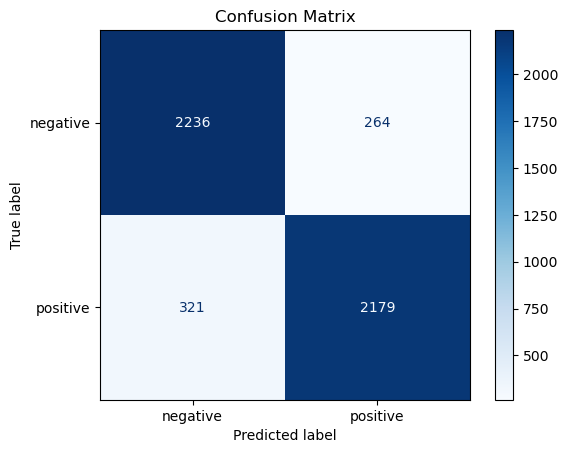

In [ ]:
vectorizer_final = CountVectorizer(max_features=10000)
X_train_val = vectorizer_final.fit_transform(X_train_val_reviews) # final training  metrix of vectors
X_test = vectorizer_final.transform(X_test_reviews)

final_model = MLPClassifier(
    solver='adam', # Optimizer -> Updates the weights of Neural Network
    hidden_layer_sizes=best_settings['hidden_layer_sizes'],
    activation=best_settings['activation'],
    alpha=best_settings['alpha'],
    batch_size=best_settings['batch_size'],
    learning_rate_init=best_settings['learning_rate_init'],
    max_iter=20,
    random_state=0,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=3
)
final_model.fit(X_train_val, y_train_val) # Final Model Trained on Training + Validation Data

test_predictions = final_model.predict(X_test) # Final Model Predictions on Test Data
test_accuracy = accuracy_score(y_test, test_predictions) #no. of correct predictions / total predictions
cm = confusion_matrix(y_test, test_predictions)

print(f"Test accuracy: {test_accuracy:.4f}")
print("Confusion matrix:")
print(cm)
print()
print("Classification report:")
print(classification_report(y_test, test_predictions, target_names=['negative', 'positive']))

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'positive'])
display.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

The final model is evaluated on the test set after the best hyperparameters have been selected. The test accuracy is about 88%, which means the model correctly classifies most reviews. The confusion matrix shows both correct and incorrect predictions for negative and positive reviews.

**(e)** Use the classifier to classify a few sentences you write yourselves. 

In [6]:
my_sentences = [
    'An excellent and touching movie with brilliant performances.',
    'This was a boring waste of time with terrible acting.',
    'The story was simple, but the film was warm and funny.',
    'I expected much more; the plot was weak and the ending was bad.',
    'Not perfect, but still an enjoyable and charming watch.'
]

X_custom = vectorizer_final.transform(my_sentences)
custom_predictions = final_model.predict(X_custom)
custom_probabilities = final_model.predict_proba(X_custom)[:, 1]

for sentence, prediction, probability in zip(my_sentences, custom_predictions, custom_probabilities):
    predicted_label = 'positive' if prediction == 1 else 'negative'
    print(f"{predicted_label} (positive probability = {probability:.4f}) -> {sentence}")

positive (positive probability = 0.8626) -> An excellent and touching movie with brilliant performances.
negative (positive probability = 0.0675) -> This was a boring waste of time with terrible acting.
positive (positive probability = 0.6542) -> The story was simple, but the film was warm and funny.
negative (positive probability = 0.1950) -> I expected much more; the plot was weak and the ending was bad.
positive (positive probability = 0.8025) -> Not perfect, but still an enjoyable and charming watch.


## Conclusion

The final model achieved about 88% test accuracy, so it can classify most IMDb reviews correctly as positive or negative.